# import libraries

In [1]:
# Import PyTorch
import torch
from torch import nn

# Import torchvision 
import torchvision
from torchvision import datasets
from torchvision.transforms import ToTensor

# Import matplotlib for visualization
import matplotlib.pyplot as plt

print(f"PyTorch version: {torch.__version__}\ntorchvision version: {torchvision.__version__}")

PyTorch version: 2.9.1+cu128
torchvision version: 0.24.1+cu128


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


# data load

In [3]:
# Setup training data
train_data = datasets.FashionMNIST(
    root="data", # where to download data to?
    train=True, # get training data
    download=True, # download data if it doesn't exist on disk
    transform=ToTensor(), # images come as PIL format, we want to turn into Torch tensors
    target_transform=None # you can transform labels as well
)

# Setup testing data
test_data = datasets.FashionMNIST(
    root="data",
    train=False, # get test data
    download=True,
    transform=ToTensor()
)

len(train_data.data), len(train_data.targets), len(test_data.data), len(test_data.targets)

(60000, 60000, 10000, 10000)

In [4]:
class_names = train_data.classes
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [5]:
train_data.targets

tensor([9, 0, 0,  ..., 3, 0, 5])

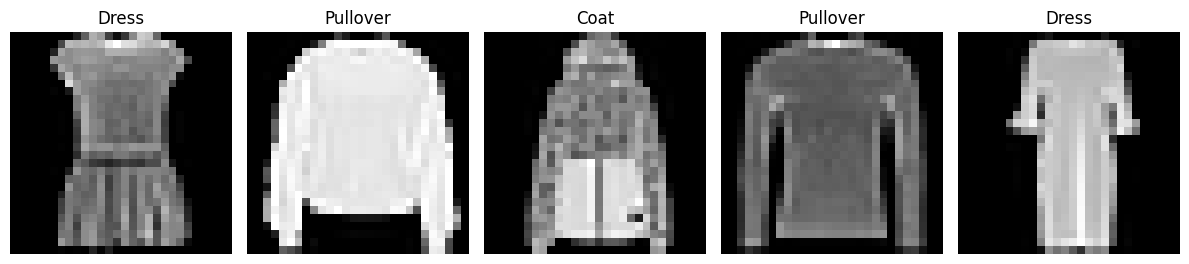

In [6]:
indices = [3, 7, 22, 37, 94]

fig, axes = plt.subplots(1, len(indices), figsize=(12, 3))

for ax, idx in zip(axes, indices):
    image, label = train_data[idx]
    ax.imshow(image.squeeze(), cmap="gray")
    ax.set_title(class_names[label])
    ax.axis("off")

plt.tight_layout()
plt.show()

In [7]:
from torch.utils.data import DataLoader

# Setup the batch size hyperparameter
BATCH_SIZE = 64

# Turn datasets into iterables (batches)
train_dataloader = DataLoader(train_data, # dataset to turn into iterable
    batch_size=BATCH_SIZE, # how many samples per batch? 
    shuffle=True # shuffle data every epoch?
)

test_dataloader = DataLoader(test_data,
    batch_size=BATCH_SIZE,
    shuffle=False # don't necessarily have to shuffle the testing data
)

# Let's check out what we've created
print(f"Dataloaders: {train_dataloader, test_dataloader}") 
print(f"Length of train dataloader: {len(train_dataloader)} batches of {BATCH_SIZE}")
print(f"Length of test dataloader: {len(test_dataloader)} batches of {BATCH_SIZE}")

Dataloaders: (<torch.utils.data.dataloader.DataLoader object at 0x000002D38059A150>, <torch.utils.data.dataloader.DataLoader object at 0x000002D380563890>)
Length of train dataloader: 938 batches of 64
Length of test dataloader: 157 batches of 64


In [8]:
# Check out what's inside the training dataloader
train_features_batch, train_labels_batch = next(iter(train_dataloader))
train_features_batch.shape, train_labels_batch.shape

(torch.Size([64, 1, 28, 28]), torch.Size([64]))

In [9]:
train_features_batch = train_features_batch.to(device)
train_labels_batch = train_labels_batch.to(device)

# 1st model

In [10]:
# Create a flatten layer
flatten_model = nn.Flatten() # all nn modules function as a model (can do a forward pass)

# Get a single sample
x = train_features_batch[0]

# Flatten the sample
output = flatten_model(x) # perform forward pass

# Print out what happened
print(f"Shape before flattening: {x.shape} -> [color_channels, height, width]")
print(f"Shape after flattening: {output.shape} -> [color_channels, height*width]")


Shape before flattening: torch.Size([1, 28, 28]) -> [color_channels, height, width]
Shape after flattening: torch.Size([1, 784]) -> [color_channels, height*width]


In [11]:
from torch import nn
class FashionMNISTModelV0(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.layer_stack = nn.Sequential(
            nn.Flatten(), # neural networks like their inputs in vector form
            nn.Linear(in_features=input_shape, out_features=hidden_units), # in_features = number of features in a data sample (784 pixels)
            nn.Linear(in_features=hidden_units, out_features=output_shape)
        )
    
    def forward(self, x):
        return self.layer_stack(x)

In [12]:
torch.manual_seed(42)

model_0 = FashionMNISTModelV0(
    input_shape=784,
    hidden_units=10,
    output_shape=len(class_names)
).to(device)

In [13]:
model_0

FashionMNISTModelV0(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
  )
)

In [14]:
import requests
from pathlib import Path 

# Download helper functions from Learn PyTorch repo (if not already downloaded)
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download")
else:
  print("Downloading helper_functions.py")
  # Note: you need the "raw" GitHub URL for this to work
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

helper_functions.py already exists, skipping download


In [15]:
# Import accuracy metric
from helper_functions import accuracy_fn # Note: could also use torchmetrics.Accuracy(task = 'multiclass', num_classes=len(class_names)).to(device)

# Setup loss function and optimizer
loss_fn = nn.CrossEntropyLoss() # this is also called "criterion"/"cost function" in some places
optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.1)

In [16]:
from timeit import default_timer as timer 
def print_train_time(start: float, end: float, device: torch.device = None):
    """Prints difference between start and end time.

    Args:
        start (float): Start time of computation (preferred in timeit format). 
        end (float): End time of computation.
        device ([type], optional): Device that compute is running on. Defaults to None.

    Returns:
        float: time between start and end in seconds (higher is longer).
    """
    total_time = end - start
    print(f"Train time on {device}: {total_time:.3f} seconds")
    return total_time

In [ ]:
from tqdm.auto import tqdm
from timeit import default_timer as timer
import numpy as np
import matplotlib.pyplot as plt


def moving_average(values, window=50):
    return np.convolve(
        values,
        np.ones(window) / window,
        mode="valid"
    )


# History
train_loss_history = []
train_acc_history = []

test_loss_history = []
test_acc_history = []


torch.manual_seed(42)

train_time_start = timer()

epochs = 5

model_0 = model_0.to(device)


for epoch in tqdm(range(epochs)):

    print(f"Epoch: {epoch}\n-------")
    model_0.train()

    train_loss = 0
    epoch_train_acc = 0

    for batch, (X, y) in enumerate(train_dataloader):

        X = X.to(device)
        y = y.to(device)

        # Forward
        y_pred = model_0(X)

        # Loss
        loss = loss_fn(y_pred, y)

        train_loss += loss.item()
        train_loss_history.append(loss.item())

        # Accuracy
        acc = accuracy_fn(
            y_true=y,
            y_pred=y_pred.argmax(dim=1)
        )

        epoch_train_acc += acc
        train_acc_history.append(acc)


        # Backprop
        optimizer.zero_grad()

        loss.backward()

        optimizer.step()


        if batch % 400 == 0:
            print(
                f"Seen {batch * len(X)}/{len(train_dataloader.dataset)} samples"
            )


    train_loss /= len(train_dataloader)
    epoch_train_acc /= len(train_dataloader)

    model_0.eval()

    test_loss = 0
    test_acc = 0


    with torch.inference_mode():

        for X, y in test_dataloader:

            X = X.to(device)
            y = y.to(device)


            test_pred = model_0(X)


            loss = loss_fn(test_pred, y)

            test_loss += loss.item()


            acc = accuracy_fn(
                y_true=y,
                y_pred=test_pred.argmax(dim=1)
            )

            test_acc += acc



    test_loss /= len(test_dataloader)
    test_acc /= len(test_dataloader)



    test_loss_history.append(test_loss)
    test_acc_history.append(test_acc)



    print(
        f"""
Train Loss: {train_loss:.4f}
Train Acc : {epoch_train_acc:.2f}%

Test Loss : {test_loss:.4f}
Test Acc  : {test_acc:.2f}%
"""
    )



train_time_end = timer()

print_train_time(
    start=train_time_start,
    end=train_time_end,
    device=str(next(model_0.parameters()).device)
)

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 0
-------
Seen 0/60000 samples
Seen 25600/60000 samples
Seen 51200/60000 samples

Train Loss: 0.4823
Train Acc : 82.94%

Test Loss : 0.5003
Test Acc  : 82.31%

Epoch: 1
-------
Seen 0/60000 samples
Seen 25600/60000 samples
Seen 51200/60000 samples

Train Loss: 0.4575
Train Acc : 83.89%

Test Loss : 0.4944
Test Acc  : 82.39%

Epoch: 2
-------
Seen 0/60000 samples
Seen 25600/60000 samples
Seen 51200/60000 samples

Train Loss: 0.4416
Train Acc : 84.57%

Test Loss : 0.4823
Test Acc  : 83.21%

Epoch: 3
-------
Seen 0/60000 samples
Seen 25600/60000 samples
Seen 51200/60000 samples

Train Loss: 0.4334
Train Acc : 84.72%

Test Loss : 0.4607
Test Acc  : 83.77%

Epoch: 4
-------
Seen 0/60000 samples
Seen 25600/60000 samples
Seen 51200/60000 samples

Train Loss: 0.4264
Train Acc : 84.99%

Test Loss : 0.4757
Test Acc  : 82.94%

Train time on cuda:0: 38.426 seconds


38.42593760008458

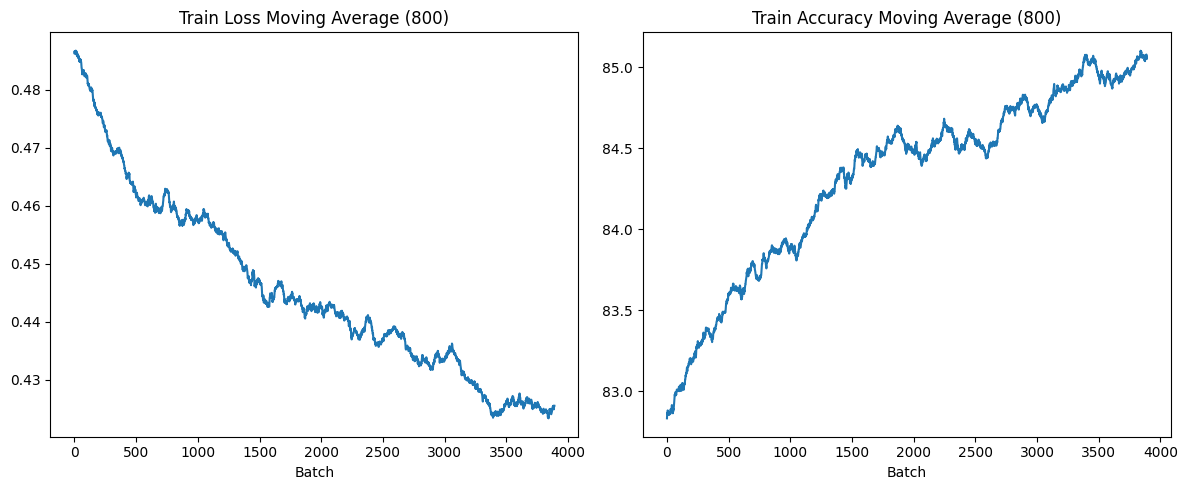

In [21]:
window = 800
train_loss_ma = moving_average(train_loss_history, window)
train_acc_ma = moving_average(train_acc_history, window)


plt.figure(figsize=(12,5))


plt.subplot(1,2,1)
plt.plot(train_loss_ma)
plt.title(f"Train Loss Moving Average ({window})")
plt.xlabel("Batch")


plt.subplot(1,2,2)
plt.plot(train_acc_ma)
plt.title(f"Train Accuracy Moving Average ({window})")
plt.xlabel("Batch")


plt.tight_layout()
plt.show()

In [22]:
def eval_model(model: torch.nn.Module, 
               data_loader: torch.utils.data.DataLoader, 
               loss_fn: torch.nn.Module, 
               accuracy_fn,
               device):

    loss, acc = 0, 0

    model.eval()

    with torch.inference_mode():
        for X, y in data_loader:

            # Move data to GPU
            X = X.to(device)
            y = y.to(device)

            # Prediction
            y_pred = model(X)

            # Loss
            loss += loss_fn(y_pred, y).item()

            # Accuracy
            acc += accuracy_fn(
                y_true=y,
                y_pred=y_pred.argmax(dim=1)
            )

        loss /= len(data_loader)
        acc /= len(data_loader)

    return {
        "model_name": model.__class__.__name__,
        "model_loss": loss,
        "model_acc": acc
    }
    
model_0_results = eval_model(
    model=model_0,
    data_loader=test_dataloader,
    loss_fn=loss_fn,
    accuracy_fn=accuracy_fn,
    device=device
)

model_0_results

{'model_name': 'FashionMNISTModelV0',
 'model_loss': 0.4756828866376998,
 'model_acc': 82.94187898089172}

# 2nd model

In [23]:
# Create a model with non-linear and linear layers
class FashionMNISTModelV1(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.layer_stack = nn.Sequential(
            nn.Flatten(), # flatten inputs into single vector
            nn.Linear(in_features=input_shape, out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units, out_features=output_shape),
            nn.ReLU()
        )
    
    def forward(self, x: torch.Tensor):
        return self.layer_stack(x)

In [24]:
torch.manual_seed(42)
model_1 = FashionMNISTModelV1(input_shape=784, # number of input features
    hidden_units=32,
    output_shape=len(class_names) # number of output classes desired
).to(device) # send model to GPU if it's available
next(model_1.parameters()).device # check model device

device(type='cuda', index=0)

In [25]:
from helper_functions import accuracy_fn
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_1.parameters(), 
                            lr=0.06)

In [26]:
def train_step(model, data_loader, loss_fn, optimizer, accuracy_fn, device):

    model.train()

    for batch, (X, y) in enumerate(data_loader):

        X, y = X.to(device), y.to(device)

        # Forward
        y_pred = model(X)

        # Loss
        loss = loss_fn(y_pred, y)

        # Accuracy
        acc = accuracy_fn(
            y_true=y,
            y_pred=y_pred.argmax(dim=1)
        )

        # Save history
        train_loss_history.append(loss.item())
        train_acc_history.append(acc)

        # Backprop
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()


        # Print info every 100 batches
        if batch % 100 == 0:
            print(
                f"Train | Batch: {batch}/{len(data_loader)} "
                f"| Loss: {loss.item():.4f} "
                f"| Acc: {acc:.2f}%"
            )



def test_step(data_loader, model, loss_fn, accuracy_fn, device):

    model.eval()

    total_loss = 0
    total_acc = 0

    with torch.inference_mode():

        for batch, (X, y) in enumerate(data_loader):

            X, y = X.to(device), y.to(device)

            test_pred = model(X)

            loss = loss_fn(test_pred, y)

            acc = accuracy_fn(
                y_true=y,
                y_pred=test_pred.argmax(dim=1)
            )

            test_loss_history.append(loss.item())
            test_acc_history.append(acc)

            total_loss += loss.item()
            total_acc += acc


            if batch % 100 == 0:
                print(
                    f"Test  | Batch: {batch}/{len(data_loader)} "
                    f"| Loss: {loss.item():.4f} "
                    f"| Acc: {acc:.2f}%"
                )


    # Epoch average
    avg_loss = total_loss / len(data_loader)
    avg_acc = total_acc / len(data_loader)

    print(
        f"\nTest Summary | Loss: {avg_loss:.4f} "
        f"| Acc: {avg_acc:.2f}%\n"
    )

In [27]:
torch.manual_seed(42)

epochs = 10

train_time_start = timer()

for epoch in tqdm(range(epochs)):

    print(f"Epoch: {epoch}\n---------")

    train_step(
        model=model_1,
        data_loader=train_dataloader,
        loss_fn=loss_fn,
        optimizer=optimizer,
        accuracy_fn=accuracy_fn,
        device=device
    )

    test_step(
        model=model_1,
        data_loader=test_dataloader,
        loss_fn=loss_fn,
        accuracy_fn=accuracy_fn,
        device=device
    )


train_time_end = timer()

print_train_time(
    start=train_time_start,
    end=train_time_end,
    device=device
)

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 0
---------
Train | Batch: 0/938 | Loss: 2.3359 | Acc: 3.12%
Train | Batch: 100/938 | Loss: 1.3027 | Acc: 59.38%
Train | Batch: 200/938 | Loss: 0.8643 | Acc: 64.06%
Train | Batch: 300/938 | Loss: 0.6309 | Acc: 79.69%
Train | Batch: 400/938 | Loss: 0.8740 | Acc: 68.75%
Train | Batch: 500/938 | Loss: 0.5418 | Acc: 78.12%
Train | Batch: 600/938 | Loss: 0.5879 | Acc: 78.12%
Train | Batch: 700/938 | Loss: 0.6189 | Acc: 75.00%
Train | Batch: 800/938 | Loss: 0.3840 | Acc: 85.94%
Train | Batch: 900/938 | Loss: 0.6154 | Acc: 84.38%
Test  | Batch: 0/157 | Loss: 0.6984 | Acc: 71.88%
Test  | Batch: 100/157 | Loss: 0.6554 | Acc: 73.44%

Test Summary | Loss: 0.5549 | Acc: 80.34%

Epoch: 1
---------
Train | Batch: 0/938 | Loss: 0.4489 | Acc: 89.06%
Train | Batch: 100/938 | Loss: 0.6168 | Acc: 79.69%
Train | Batch: 200/938 | Loss: 0.5759 | Acc: 76.56%
Train | Batch: 300/938 | Loss: 0.5038 | Acc: 82.81%
Train | Batch: 400/938 | Loss: 0.5436 | Acc: 79.69%
Train | Batch: 500/938 | Loss: 0.4337 | A

73.9929413999198

In [28]:
window = 50

train_loss_ma = moving_average(train_loss_history, window)
train_acc_ma = moving_average(train_acc_history, window)

test_loss_ma = moving_average(test_loss_history, window)
test_acc_ma = moving_average(test_acc_history, window)

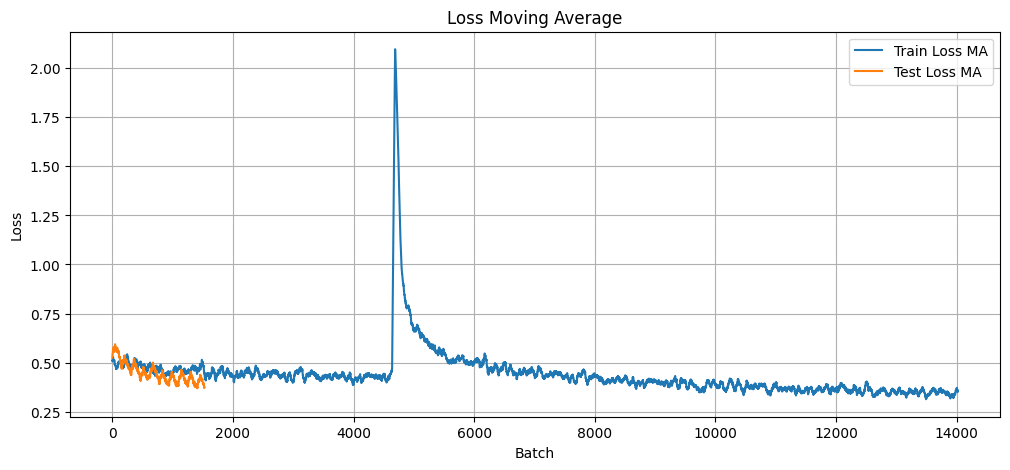

In [29]:
plt.figure(figsize=(12,5))

plt.plot(train_loss_ma, label="Train Loss MA")
plt.plot(test_loss_ma, label="Test Loss MA")

plt.title("Loss Moving Average")
plt.xlabel("Batch")
plt.ylabel("Loss")
plt.legend()
plt.grid()

plt.show()

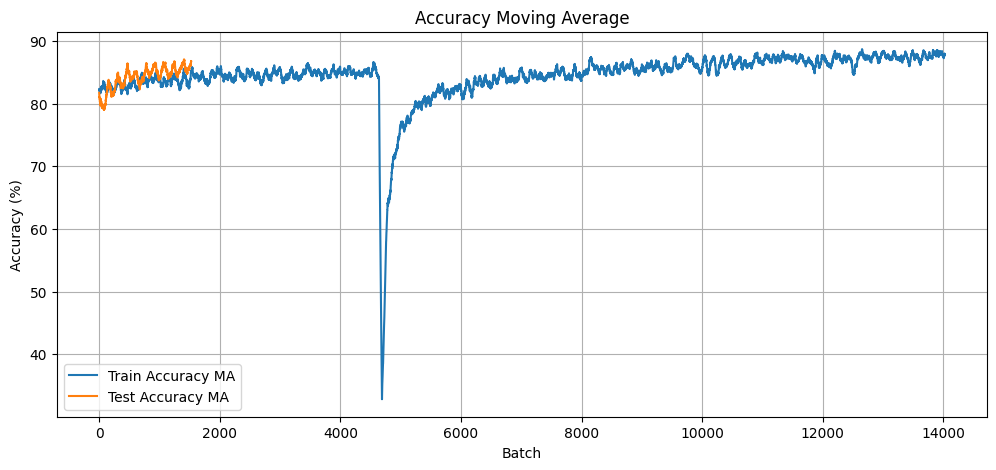

In [30]:
plt.figure(figsize=(12,5))

plt.plot(train_acc_ma, label="Train Accuracy MA")
plt.plot(test_acc_ma, label="Test Accuracy MA")

plt.title("Accuracy Moving Average")
plt.xlabel("Batch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid()

plt.show()

In [31]:
# Move values to device
torch.manual_seed(42)
def eval_model(model: torch.nn.Module, 
               data_loader: torch.utils.data.DataLoader, 
               loss_fn: torch.nn.Module, 
               accuracy_fn, 
               device: torch.device = device):

    loss, acc = 0, 0
    model.eval()
    with torch.inference_mode():
        for X, y in data_loader:
            # Send data to the target device
            X, y = X.to(device), y.to(device)
            y_pred = model(X)
            loss += loss_fn(y_pred, y)
            acc += accuracy_fn(y_true=y, y_pred=y_pred.argmax(dim=1))
        
        # Scale loss and acc
        loss /= len(data_loader)
        acc /= len(data_loader)
    return {"model_name": model.__class__.__name__, # only works when model was created with a class
            "model_loss": loss.item(),
            "model_acc": acc}

# Calculate model 1 results with device-agnostic code 
model_1_results = eval_model(model=model_1, data_loader=test_dataloader,
    loss_fn=loss_fn, accuracy_fn=accuracy_fn,
    device=device
)
model_1_results

{'model_name': 'FashionMNISTModelV1',
 'model_loss': 0.39737245440483093,
 'model_acc': 86.046974522293}

# 3rd model

In [32]:
# Create a convolutional neural network 
class FashionMNISTModelV2(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape, 
                      out_channels=hidden_units, 
                      kernel_size=3, # how big is the square that's going over the image?
                      stride=1, # default
                      padding=1),# options = "valid" (no padding) or "same" (output has same shape as input) or int for specific number 
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units, 
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,
                         stride=2) # default stride value is same as kernel_size
        )
        self.block_2 = nn.Sequential(
            nn.Conv2d(hidden_units, hidden_units, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(hidden_units, hidden_units, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            # Where did this in_features shape come from? 
            # It's because each layer of our network compresses and changes the shape of our input data.
            nn.Linear(in_features=hidden_units*7*7, 
                      out_features=output_shape)
        )
    
    def forward(self, x: torch.Tensor):
        x = self.block_1(x)
        # print(x.shape)
        x = self.block_2(x)
        # print(x.shape)
        x = self.classifier(x)
        # print(x.shape)
        return x

torch.manual_seed(42)
model_2 = FashionMNISTModelV2(input_shape=1, 
    hidden_units=10, 
    output_shape=len(class_names)).to(device)
model_2

FashionMNISTModelV2(
  (block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

In [35]:
# Setup loss and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_2.parameters(), 
                             lr=0.05)

In [36]:
torch.manual_seed(42)

epochs = 15

train_time_start = timer()

for epoch in tqdm(range(epochs)):

    print(f"Epoch: {epoch}\n---------")

    train_step(
        model=model_2,
        data_loader=train_dataloader,
        loss_fn=loss_fn,
        optimizer=optimizer,
        accuracy_fn=accuracy_fn,
        device=device
    )

    test_step(
        model=model_2,
        data_loader=test_dataloader,
        loss_fn=loss_fn,
        accuracy_fn=accuracy_fn,
        device=device
    )


train_time_end = timer()

print_train_time(
    start=train_time_start,
    end=train_time_end,
    device=device
)

  0%|          | 0/15 [00:00<?, ?it/s]

Epoch: 0
---------
Train | Batch: 0/938 | Loss: 0.4282 | Acc: 82.81%
Train | Batch: 100/938 | Loss: 0.3638 | Acc: 85.94%
Train | Batch: 200/938 | Loss: 0.3522 | Acc: 89.06%
Train | Batch: 300/938 | Loss: 0.2801 | Acc: 89.06%
Train | Batch: 400/938 | Loss: 0.3816 | Acc: 85.94%
Train | Batch: 500/938 | Loss: 0.3674 | Acc: 84.38%
Train | Batch: 600/938 | Loss: 0.3607 | Acc: 85.94%
Train | Batch: 700/938 | Loss: 0.3570 | Acc: 82.81%
Train | Batch: 800/938 | Loss: 0.2435 | Acc: 89.06%
Train | Batch: 900/938 | Loss: 0.4077 | Acc: 85.94%
Test  | Batch: 0/157 | Loss: 0.5205 | Acc: 81.25%
Test  | Batch: 100/157 | Loss: 0.4076 | Acc: 82.81%

Test Summary | Loss: 0.3915 | Acc: 85.86%

Epoch: 1
---------
Train | Batch: 0/938 | Loss: 0.2469 | Acc: 98.44%
Train | Batch: 100/938 | Loss: 0.5707 | Acc: 79.69%
Train | Batch: 200/938 | Loss: 0.5298 | Acc: 81.25%
Train | Batch: 300/938 | Loss: 0.4249 | Acc: 81.25%
Train | Batch: 400/938 | Loss: 0.3411 | Acc: 84.38%
Train | Batch: 500/938 | Loss: 0.3695 | 

137.41482179996092

In [37]:
window = 50

train_loss_ma = moving_average(train_loss_history, window)
train_acc_ma = moving_average(train_acc_history, window)

test_loss_ma = moving_average(test_loss_history, window)
test_acc_ma = moving_average(test_acc_history, window)

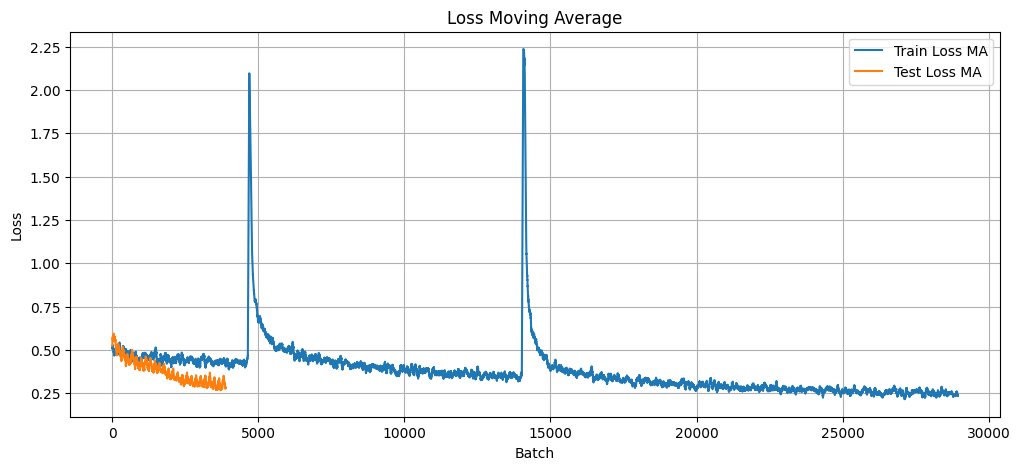

In [38]:
plt.figure(figsize=(12,5))

plt.plot(train_loss_ma, label="Train Loss MA")
plt.plot(test_loss_ma, label="Test Loss MA")

plt.title("Loss Moving Average")
plt.xlabel("Batch")
plt.ylabel("Loss")
plt.legend()
plt.grid()

plt.show()

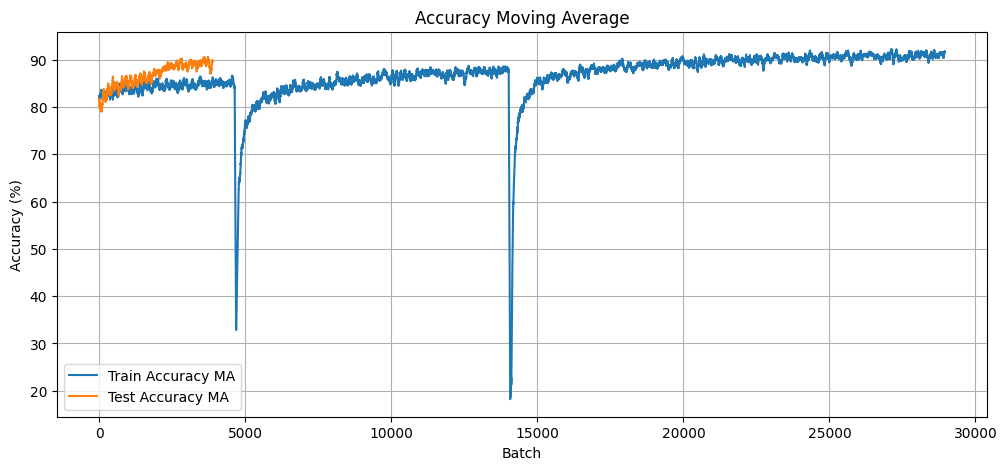

In [39]:
plt.figure(figsize=(12,5))

plt.plot(train_acc_ma, label="Train Accuracy MA")
plt.plot(test_acc_ma, label="Test Accuracy MA")

plt.title("Accuracy Moving Average")
plt.xlabel("Batch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid()

plt.show()

In [42]:
# Move values to device
torch.manual_seed(42)
def eval_model(model: torch.nn.Module, 
               data_loader: torch.utils.data.DataLoader, 
               loss_fn: torch.nn.Module, 
               accuracy_fn, 
               device: torch.device = device):

    loss, acc = 0, 0
    model.eval()
    with torch.inference_mode():
        for X, y in data_loader:
            # Send data to the target device
            X, y = X.to(device), y.to(device)
            y_pred = model(X)
            loss += loss_fn(y_pred, y)
            acc += accuracy_fn(y_true=y, y_pred=y_pred.argmax(dim=1))
        
        # Scale loss and acc
        loss /= len(data_loader)
        acc /= len(data_loader)
    return {"model_name": model.__class__.__name__, # only works when model was created with a class
            "model_loss": loss.item(),
            "model_acc": acc}

# Calculate model 1 results with device-agnostic code 
model_2_results = eval_model(model=model_2, data_loader=test_dataloader,
    loss_fn=loss_fn, accuracy_fn=accuracy_fn,
    device=device
)
model_2_results

{'model_name': 'FashionMNISTModelV2',
 'model_loss': 0.30414602160453796,
 'model_acc': 88.62460191082802}

# results

In [46]:
import pandas as pd
compare_results = pd.DataFrame([model_0_results, model_1_results, model_2_results])
compare_results

,model_name,model_loss,model_acc
0,FashionMNISTModelV0,0.475683,82.941879
1,FashionMNISTModelV1,0.397372,86.046975
2,FashionMNISTModelV2,0.304146,88.624602


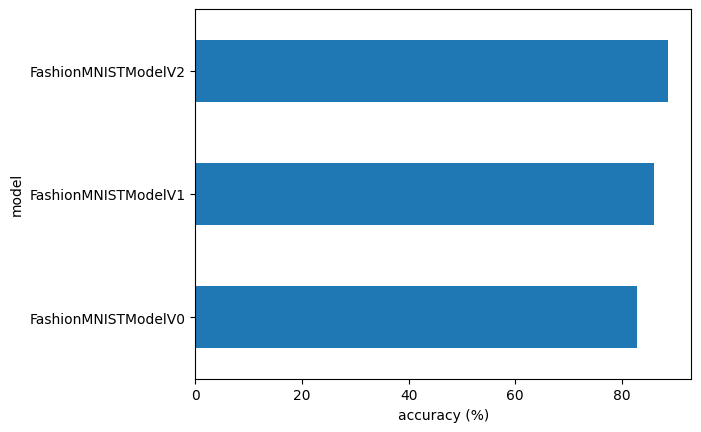

In [48]:
# Visualize our model results
compare_results.set_index("model_name")["model_acc"].plot(kind="barh")
plt.xlabel("accuracy (%)")
plt.ylabel("model");

In [49]:
def make_predictions(model: torch.nn.Module, data: list, device: torch.device = device):
    pred_probs = []
    model.eval()
    with torch.inference_mode():
        for sample in data:
            # Prepare sample
            sample = torch.unsqueeze(sample, dim=0).to(device) # Add an extra dimension and send sample to device

            # Forward pass (model outputs raw logit)
            pred_logit = model(sample)

            # Get prediction probability (logit -> prediction probability)
            pred_prob = torch.softmax(pred_logit.squeeze(), dim=0) # note: perform softmax on the "logits" dimension, not "batch" dimension (in this case we have a batch size of 1, so can perform on dim=0)

            # Get pred_prob off GPU for further calculations
            pred_probs.append(pred_prob.cpu())
            
    # Stack the pred_probs to turn list into a tensor
    return torch.stack(pred_probs)

In [50]:
import random
random.seed(42)
test_samples = []
test_labels = []
for sample, label in random.sample(list(test_data), k=9):
    test_samples.append(sample)
    test_labels.append(label)

# View the first test sample shape and label
print(f"Test sample image shape: {test_samples[0].shape}\nTest sample label: {test_labels[0]} ({class_names[test_labels[0]]})")

Test sample image shape: torch.Size([1, 28, 28])
Test sample label: 5 (Sandal)


In [51]:
# Make predictions on test samples with model 2
pred_probs= make_predictions(model=model_2, 
                             data=test_samples)

# View first two prediction probabilities list
pred_probs[:2]

tensor([[1.1405e-08, 5.0060e-10, 3.4113e-10, 9.1878e-10, 1.0704e-10, 9.9928e-01,
         7.7815e-08, 3.5337e-07, 5.7775e-07, 7.2123e-04],
        [7.1926e-02, 7.8830e-01, 3.2681e-04, 9.1455e-02, 2.3537e-02, 4.1895e-06,
         2.4344e-02, 9.5619e-06, 9.1796e-05, 5.6558e-06]])

In [52]:
# Turn the prediction probabilities into prediction labels by taking the argmax()
pred_classes = pred_probs.argmax(dim=1)
pred_classes

tensor([5, 1, 7, 2, 3, 0, 4, 7, 1])

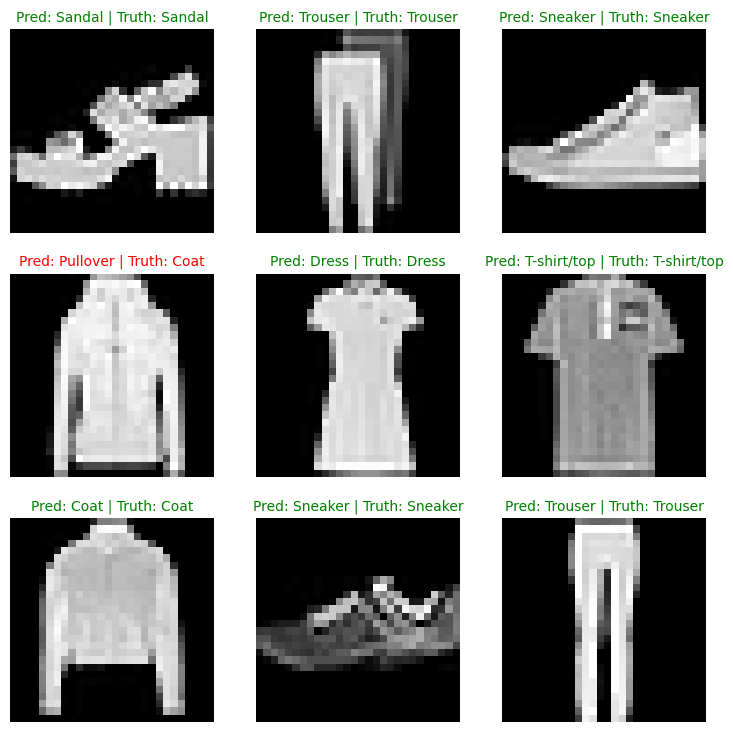

In [53]:
# Plot predictions
plt.figure(figsize=(9, 9))
nrows = 3
ncols = 3
for i, sample in enumerate(test_samples):
  # Create a subplot
  plt.subplot(nrows, ncols, i+1)

  # Plot the target image
  plt.imshow(sample.squeeze(), cmap="gray")

  # Find the prediction label (in text form, e.g. "Sandal")
  pred_label = class_names[pred_classes[i]]

  # Get the truth label (in text form, e.g. "T-shirt")
  truth_label = class_names[test_labels[i]] 

  # Create the title text of the plot
  title_text = f"Pred: {pred_label} | Truth: {truth_label}"
  
  # Check for equality and change title colour accordingly
  if pred_label == truth_label:
      plt.title(title_text, fontsize=10, c="g") # green text if correct
  else:
      plt.title(title_text, fontsize=10, c="r") # red text if wrong
  plt.axis(False);